# Análisis de Sentimiento Airbnb - Porcentajes corregidos

Esta versión muestra los porcentajes en Colab, Excel e informe en formato correcto: 80.04%, 17.36%, etc.

In [ ]:
# ============================================================
# ANÁLISIS DE SENTIMIENTO AIRBNB
# Grupo: 4
# Integrantes: Sissy Fernandez, Jorge Zayerzs, Renzo Romero, Andres Condori, Alex
# Archivo esperado: G4_mod.xlsx
# Hoja usada: Reviews


In [1]:
# ============================================================

!pip -q install pandas numpy matplotlib scikit-learn openpyxl python-docx wordcloud

import os
import re
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import display, Markdown
from google.colab import files

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

from docx import Document
from docx.shared import Inches

try:
    from wordcloud import WordCloud
    WORDCLOUD_OK = True
except:
    WORDCLOUD_OK = False


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. Cargar archivo

In [2]:
# ============================================================

display(Markdown("# 1. Cargar archivo"))
display(Markdown("Sube tu archivo **G4_mod.xlsx**."))

uploaded = files.upload()
input_file = list(uploaded.keys())[0]

sheet_name = "Reviews"
comment_col = "Reseña (Debe estar solo en español)"
id_col = "ID Airbnb"

df_raw = pd.read_excel(input_file, sheet_name=sheet_name)

display(Markdown("## Vista inicial de la hoja Reviews"))
display(df_raw.head())

display(Markdown("## Columnas encontradas"))
display(pd.DataFrame({"Columnas": df_raw.columns.tolist()}))

if comment_col not in df_raw.columns:
    raise ValueError(f"No se encontró la columna exacta: {comment_col}. Revisa el nombre en la hoja Reviews.")


# 1. Cargar archivo

Sube tu archivo **G4_mod.xlsx**.

Saving G4_mod_finale.xlsx to G4_mod_finale.xlsx


## Vista inicial de la hoja Reviews

,Fecha de colecta,ID Airbnb,#Review,Reseña (Debe estar solo en español)
0,20/10/2024,981291392324367211,1,.
1,20/10/2024,981291392324367211,2,"Agradable lugar, tiene todo lo necesario."
2,20/10/2024,981291392324367211,3,Muy buena locación y muy agradable el Apto!
3,20/10/2024,981291392324367211,4,Bonito loft con buenas amenidades y excelente ...
4,20/10/2024,981291392324367211,5,Francisco muchas gracias por el espacio.\nEstá...


## Columnas encontradas

,Columnas
0,Fecha de colecta
1,ID Airbnb
2,#Review
3,Reseña (Debe estar solo en español)


In [ ]:
# ============================================================
# 2. Limpieza de comentarios

In [3]:
# ============================================================

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def normalize_text(text):
    text = clean_text(text).lower()
    text = text.translate(str.maketrans("áéíóúüñ", "aeiouun"))
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = df_raw.copy()
df["comentario_original"] = df[comment_col].apply(clean_text)
df["comentario_limpio"] = df["comentario_original"].apply(normalize_text)

invalid_values = {"", ".", "-", "nan", "none", "null"}
valid_mask = ~df["comentario_limpio"].str.lower().isin(invalid_values)

df_valid = df[valid_mask].copy()
df_invalid = df[~valid_mask].copy()

display(Markdown("# 2. Depuración de comentarios"))
resumen_dep = pd.DataFrame({
    "Indicador": ["Filas totales", "Comentarios válidos", "Comentarios descartados"],
    "Valor": [len(df_raw), len(df_valid), len(df_invalid)]
})
display(resumen_dep)

display(Markdown("## Muestra de comentarios válidos"))
display(df_valid[[id_col, comment_col, "comentario_limpio"]].head(10))

if len(df_valid) < 10:
    raise ValueError("Hay muy pocos comentarios válidos. Revisa si estás subiendo el archivo correcto.")


# 2. Depuración de comentarios

,Indicador,Valor
0,Filas totales,2816
1,Comentarios válidos,2797
2,Comentarios descartados,19


## Muestra de comentarios válidos

,ID Airbnb,Reseña (Debe estar solo en español),comentario_limpio
1,981291392324367211,"Agradable lugar, tiene todo lo necesario.",agradable lugar tiene todo lo necesario
2,981291392324367211,Muy buena locación y muy agradable el Apto!,muy buena locacion y muy agradable el apto
3,981291392324367211,Bonito loft con buenas amenidades y excelente ...,bonito loft con buenas amenidades y excelente ...
4,981291392324367211,Francisco muchas gracias por el espacio.\nEstá...,francisco muchas gracias por el espacio esta m...
5,981291392324367211,Odio dejar evaluaciones menos que estelares aq...,odio dejar evaluaciones menos que estelares aq...
6,981291392324367211,gracias,gracias
7,981291392324367211,¡Se encuentra en el Barranco y se puede camina...,se encuentra en el barranco y se puede caminar...
8,981291392324367211,Fue muy cómodo y acogedor,fue muy comodo y acogedor
9,981291392324367211,"Todo increíble, el departamento era muy acoged...",todo increible el departamento era muy acogedo...
10,981291392324367211,Todo fue excelente; este es un lugar fantástic...,todo fue excelente este es un lugar fantastico...


In [ ]:
# ============================================================
# 3. Diccionarios para sentimiento, emociones y aspectos

In [4]:
# ============================================================

positive_words = [
    "excelente","perfecto","perfecta","bueno","buena","buen","bonito","bonita","agradable",
    "limpio","limpia","recomiendo","recomendado","genial","comodo","comoda","cómodo","cómoda",
    "atento","atenta","amable","seguro","segura","impecable","fantastico","fantastica",
    "maravilloso","maravillosa","increible","tranquilo","tranquila","facil","cerca","centrico",
    "moderno","moderna","hermoso","hermosa","espacioso","espaciosa","funcional","bien",
    "encanto","encantador","encantadora","volveria","volvería","gracias","hospitalidad",
    "rapido","rapida","ubicacion","ubicación","calidad","precioso","preciosa"
]

negative_words = [
    "ruido","ruidoso","ruidosa","problema","problemas","malo","mala","mal","sucio","sucia",
    "trafico","tráfico","pequeño","pequena","pequeña","demora","dificil","difícil",
    "incomodo","incomoda","frio","frío","calor","lento","lenta","caro","cara","deficiente",
    "falta","faltaba","fallo","falló","dañado","dañada","olor","humedad","moho","lejos",
    "peligroso","peligrosa","queja","molesto","molesta","decepcion","decepción","suciedad"
]

emotion_dict = {
    "Alegría": ["feliz","alegre","encantado","encantada","maravilloso","maravillosa","increible","fantastico","fantastica"],
    "Satisfacción": ["excelente","perfecto","perfecta","bueno","buena","agradable","comodo","comoda","limpio","limpia","recomiendo"],
    "Confianza": ["seguro","segura","confiable","amable","atento","atenta","gracias","hospitalidad","rapido"],
    "Sorpresa": ["sorprendido","sorprendida","mejor","supero","superó","increible"],
    "Tristeza": ["triste","lamentable","pena"],
    "Frustración": ["demora","dificil","problema","problemas","fallo","faltaba"],
    "Enojo": ["molesto","molesta","terrible","horrible","pesimo","pésimo","queja","ruido"],
    "Decepción": ["decepcion","decepción","esperaba","malo","mala","deficiente"]
}

aspects = {
    "Ubicación": ["ubicacion","zona","cerca","centro","barranco","miraflores","restaurante","transporte","playa"],
    "Limpieza": ["limpio","limpia","limpieza","sucio","sucia","suciedad","olor","humedad","moho"],
    "Atención/Anfitrión": ["anfitrion","host","dueno","duena","atencion","amable","comunicacion"],
    "Instalaciones/Amenities": ["departamento","apto","apartamento","cama","bano","baño","cocina","ducha","piscina","ascensor","amenidades"],
    "Seguridad": ["seguro","segura","seguridad","peligroso","peligrosa","portero","vigilancia"],
    "Ruido": ["ruido","ruidoso","ruidosa","bulla","molesto","molesta","trafico"],
    "Wifi/Conectividad": ["wifi","internet","conexion","senal","señal"]
}

stopwords_es = set("""
a al algo algun alguna algunas alguno algunos ante antes aqui así como con contra cual cuando de del desde donde dos el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba estaban estado estas este esto estos fue fueron ha han hasta hay la las le les lo los mas me mi mis mucho muy no nos o para pero por que se si sin sobre son su sus te tiene todo todos tu un una unas uno unos y ya lugar departamento apartamento apto airbnb
""".split())


In [ ]:
# ============================================================
# 4. Sentimiento y emociones

In [5]:
# ============================================================

def count_matches(text, words):
    text = normalize_text(text)
    return sum(1 for w in words if re.search(r"\b" + re.escape(normalize_text(w)) + r"\b", text))

def sentiment_score(text):
    pos = count_matches(text, positive_words)
    neg = count_matches(text, negative_words)
    score = pos - neg
    if score >= 3:
        s5 = "Muy positivo"
        s3 = "Positivo"
    elif score >= 1:
        s5 = "Positivo"
        s3 = "Positivo"
    elif score == 0:
        s5 = "Neutral"
        s3 = "Neutral"
    elif score <= -2:
        s5 = "Muy negativo"
        s3 = "Negativo"
    else:
        s5 = "Negativo"
        s3 = "Negativo"
    return pd.Series([pos, neg, score, s3, s5])

def classify_emotion(text, s3):
    scores = {emo: count_matches(text, words) for emo, words in emotion_dict.items()}
    best = max(scores, key=scores.get)
    if scores[best] == 0:
        if s3 == "Positivo":
            return "Satisfacción"
        elif s3 == "Negativo":
            return "Frustración"
        else:
            return "Neutralidad"
    return best

df_valid[["palabras_positivas","palabras_negativas","score_sentimiento","sentimiento_3","sentimiento_5"]] = df_valid["comentario_limpio"].apply(sentiment_score)
df_valid["emocion"] = df_valid.apply(lambda r: classify_emotion(r["comentario_limpio"], r["sentimiento_3"]), axis=1)


In [ ]:
# ============================================================
# 5. ABSA

In [6]:
# ============================================================

absa_rows = []
for idx, row in df_valid.iterrows():
    txt = row["comentario_limpio"]
    for asp, keys in aspects.items():
        if any(re.search(r"\b" + re.escape(normalize_text(k)) + r"\b", txt) for k in keys):
            absa_rows.append({
                "ID Airbnb": row[id_col] if id_col in df_valid.columns else idx,
                "Aspecto": asp,
                "Sentimiento": row["sentimiento_3"],
                "Score": row["score_sentimiento"],
                "Comentario": row["comentario_original"]
            })

absa_df = pd.DataFrame(absa_rows)

if len(absa_df) > 0:
    absa_summary = pd.crosstab(absa_df["Aspecto"], absa_df["Sentimiento"]).reset_index()
    for col in ["Positivo", "Neutral", "Negativo"]:
        if col not in absa_summary.columns:
            absa_summary[col] = 0
    absa_summary = absa_summary[["Aspecto", "Positivo", "Neutral", "Negativo"]]
    absa_summary["Total"] = absa_summary[["Positivo", "Neutral", "Negativo"]].sum(axis=1)
    absa_summary["% positivo"] = absa_summary["Positivo"] / absa_summary["Total"]
    absa_summary["% negativo"] = absa_summary["Negativo"] / absa_summary["Total"]
else:
    absa_summary = pd.DataFrame(columns=["Aspecto", "Positivo", "Neutral", "Negativo", "Total", "% positivo", "% negativo"])


In [ ]:
# ============================================================
# 6. Palabras, Bigramas y Trigramas SIN ERROR

In [7]:
# ============================================================

def tokenizer(text):
    text = normalize_text(text)
    toks = re.findall(r"\b[a-z]{3,}\b", text)
    return [w for w in toks if w not in stopwords_es]

tokens = []
for t in df_valid["comentario_limpio"]:
    tokens.extend(tokenizer(t))

palabras_df = pd.DataFrame(Counter(tokens).most_common(100), columns=["Palabra", "Frecuencia"])

def make_ngrams(texts, n=2, top=50):
    counts = Counter()
    for text in texts:
        toks = tokenizer(text)
        if len(toks) >= n:
            grams = [" ".join(toks[i:i+n]) for i in range(len(toks)-n+1)]
            counts.update(grams)
    return pd.DataFrame(counts.most_common(top), columns=["N-grama", "Frecuencia"])

bigramas_df = make_ngrams(df_valid["comentario_limpio"], n=2, top=50)
trigramas_df = make_ngrams(df_valid["comentario_limpio"], n=3, top=50)

display(Markdown("# 3. Verificación correcta de n-gramas"))
display(pd.DataFrame({
    "Indicador": ["Palabras encontradas", "Bigramas encontrados", "Trigramas encontrados"],
    "Cantidad": [len(palabras_df), len(bigramas_df), len(trigramas_df)]
}))

display(Markdown("## Top Bigramas"))
display(bigramas_df.head(20))

display(Markdown("## Top Trigramas"))
display(trigramas_df.head(20))


# 3. Verificación correcta de n-gramas

,Indicador,Cantidad
0,Palabras encontradas,100
1,Bigramas encontrados,50
2,Trigramas encontrados,50


## Top Bigramas

,N-grama,Frecuencia
0,excelente ubicacion,124
1,muchas gracias,102
2,bien ubicado,101
3,buena ubicacion,90
4,tal fotos,63
5,limpio ordenado,60
6,ubicacion perfecta,51
7,bien equipado,48
8,siempre estuvo,47
9,muchos restaurantes,45


## Top Trigramas

,N-grama,Frecuencia
0,poca distancia pie,33
1,orden valoraciones relevantes,24
2,sigue nuestras aventuras,18
3,estilo vida promovemos,18
4,vida promovemos esperamos,18
5,visita verdadero placer,17
6,verdadero placer sigue,17
7,placer sigue nuestras,17
8,nuestras aventuras instagram,17
9,aventuras instagram depahostpe,17


In [ ]:
# ============================================================
# 7. Topic Modeling y Clustering SIN ERROR

In [8]:
# ============================================================

texts_topic = [" ".join(tokenizer(t)) for t in df_valid["comentario_limpio"]]
texts_topic = [t if t.strip() else "sin contenido" for t in texts_topic]

try:
    tfidf = TfidfVectorizer(max_features=800, min_df=2)
    X_tfidf = tfidf.fit_transform(texts_topic)
except:
    tfidf = TfidfVectorizer(max_features=800, min_df=1)
    X_tfidf = tfidf.fit_transform(texts_topic)

n_topics = min(8, max(1, X_tfidf.shape[1]))
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_
terms = tfidf.get_feature_names_out()

topic_rows = []
for topic_idx, topic in enumerate(H):
    top_terms = [terms[i] for i in topic.argsort()[-10:][::-1]]
    topic_rows.append({
        "Tema": f"Tema {topic_idx+1}",
        "Palabras clave": ", ".join(top_terms),
        "Cantidad estimada": int((W.argmax(axis=1) == topic_idx).sum())
    })

temas_df = pd.DataFrame(topic_rows)
df_valid["tema_principal"] = [f"Tema {i+1}" for i in W.argmax(axis=1)]

k = min(4, len(df_valid))
if k >= 2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_valid["cluster"] = kmeans.fit_predict(X_tfidf)
else:
    df_valid["cluster"] = 0

clusters_df = df_valid.groupby("cluster").agg(
    comentarios=("comentario_limpio", "count"),
    score_promedio=("score_sentimiento", "mean")
).reset_index()


In [ ]:
# ============================================================
# 8. KPIs

In [9]:
# ============================================================

total_rows = len(df_raw)
valid_comments = len(df_valid)
discarded_comments = len(df_invalid)

sent_counts = df_valid["sentimiento_3"].value_counts()
pos_count = int(sent_counts.get("Positivo", 0))
neu_count = int(sent_counts.get("Neutral", 0))
neg_count = int(sent_counts.get("Negativo", 0))

pct_pos = pos_count / valid_comments
pct_neu = neu_count / valid_comments
pct_neg = neg_count / valid_comments
sentimiento_neto = pct_pos - pct_neg

aspecto_mejor = absa_summary.sort_values("% positivo", ascending=False)["Aspecto"].iloc[0] if len(absa_summary) else "No identificado"
aspecto_critico = absa_summary.sort_values("% negativo", ascending=False)["Aspecto"].iloc[0] if len(absa_summary) else "No identificado"
emocion_predominante = df_valid["emocion"].value_counts().idxmax()

kpis_df = pd.DataFrame({
    "Indicador": [
        "Filas totales", "Comentarios válidos", "Comentarios descartados",
        "% positivos", "% neutrales", "% negativos",
        "Índice general de satisfacción", "Índice de sentimiento neto",
        "Aspecto mejor valorado", "Aspecto crítico", "Emoción predominante"
    ],
    "Valor": [
        total_rows, valid_comments, discarded_comments,
        pct_pos, pct_neu, pct_neg, pct_pos, sentimiento_neto,
        aspecto_mejor, aspecto_critico, emocion_predominante
    ]
})

display(Markdown("# 4. KPIs ejecutivos"))
kpis_view = kpis_df.copy()
for i in range(len(kpis_view)):
    ind = str(kpis_view.loc[i, "Indicador"])
    if ind.startswith("%") or "Índice" in ind:
        kpis_view.loc[i, "Valor"] = f"{float(kpis_view.loc[i, 'Valor']):.2%}"
display(kpis_view)


def format_percent_columns(df_in):
    """Devuelve una copia para visualizar porcentajes en formato 80.04% en Colab."""
    df_out = df_in.copy()
    for col in df_out.columns:
        if "porcentaje" in str(col).lower() or str(col).strip().startswith("%") or "índice" in str(col).lower() or "indice" in str(col).lower():
            df_out[col] = df_out[col].apply(lambda x: f"{float(x):.2%}" if isinstance(x, (int, float, np.floating)) and not pd.isna(x) else x)
    return df_out


# 4. KPIs ejecutivos

,Indicador,Valor
0,Filas totales,2816
1,Comentarios válidos,2797
2,Comentarios descartados,19
3,% positivos,79.98%
4,% neutrales,17.41%
5,% negativos,2.61%
6,Índice general de satisfacción,79.98%
7,Índice de sentimiento neto,77.37%
8,Aspecto mejor valorado,Seguridad
9,Aspecto crítico,Ruido


In [ ]:
# ============================================================
# 9. Visualización de resultados

# 5. Gráficos principales

## Distribución de sentimientos

,Sentimiento,Cantidad,Porcentaje
0,Positivo,2237,79.98%
1,Neutral,487,17.41%
2,Negativo,73,2.61%


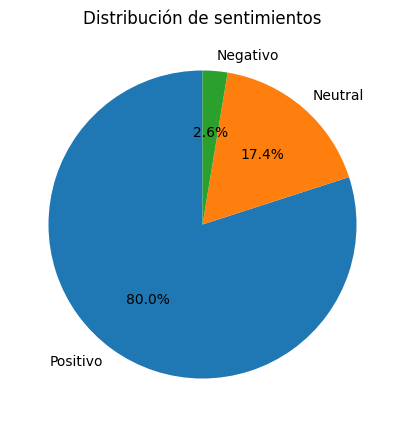

## Sentimiento en 5 clases

,Sentimiento,Cantidad,Porcentaje
0,Muy positivo,1190,42.55%
1,Positivo,1047,37.43%
2,Neutral,487,17.41%
3,Negativo,50,1.79%
4,Muy negativo,23,0.82%


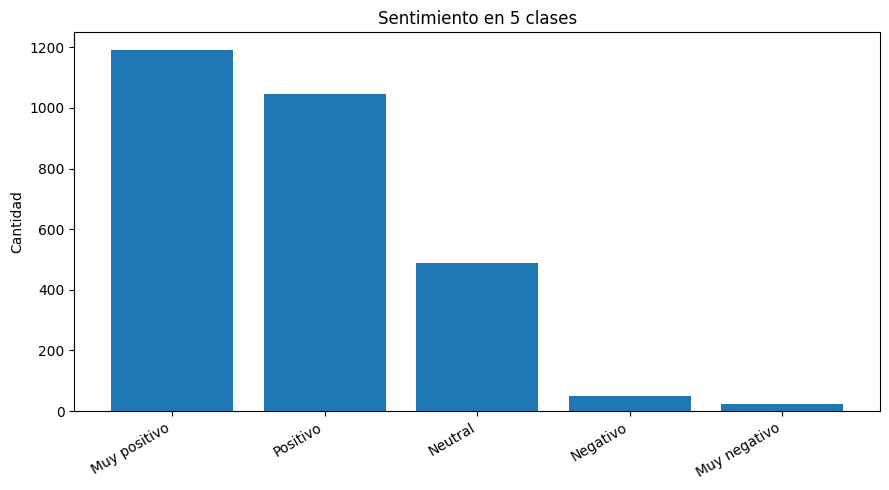

## Emociones

,Emoción,Cantidad,Porcentaje
0,Satisfacción,1789,63.96%
1,Neutralidad,430,15.37%
2,Confianza,328,11.73%
3,Alegría,145,5.18%
4,Frustración,45,1.61%
5,Sorpresa,33,1.18%
6,Enojo,19,0.68%
7,Tristeza,5,0.18%
8,Decepción,3,0.11%


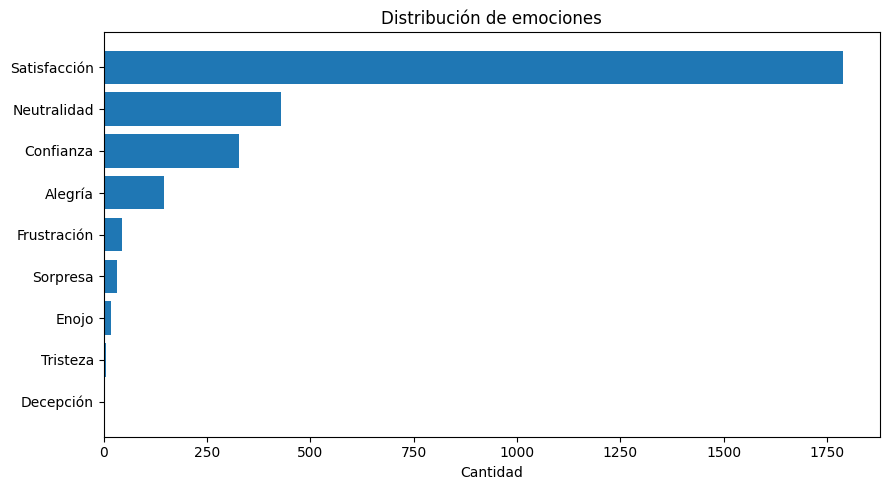

## Aspectos ABSA

Sentimiento,Aspecto,Positivo,Neutral,Negativo,Total,% positivo,% negativo
0,Atención/Anfitrión,602,59,20,681,88.40%,2.94%
1,Instalaciones/Amenities,856,87,45,988,86.64%,4.55%
2,Limpieza,482,20,25,527,91.46%,4.74%
3,Ruido,73,24,25,122,59.84%,20.49%
4,Seguridad,166,7,2,175,94.86%,1.14%
5,Ubicación,844,63,16,923,91.44%,1.73%
6,Wifi/Conectividad,39,12,1,52,75.00%,1.92%


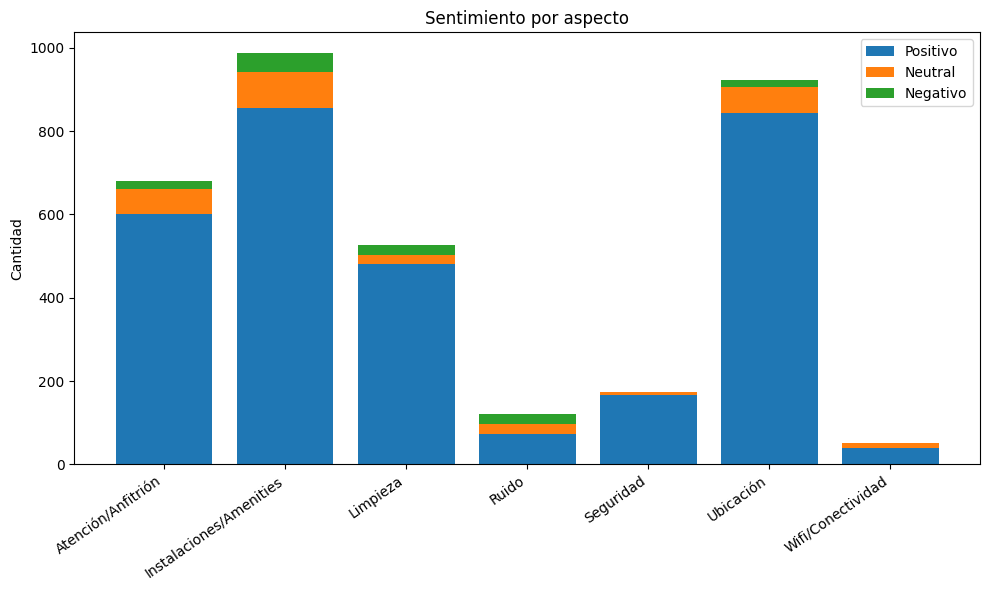

## Bigramas

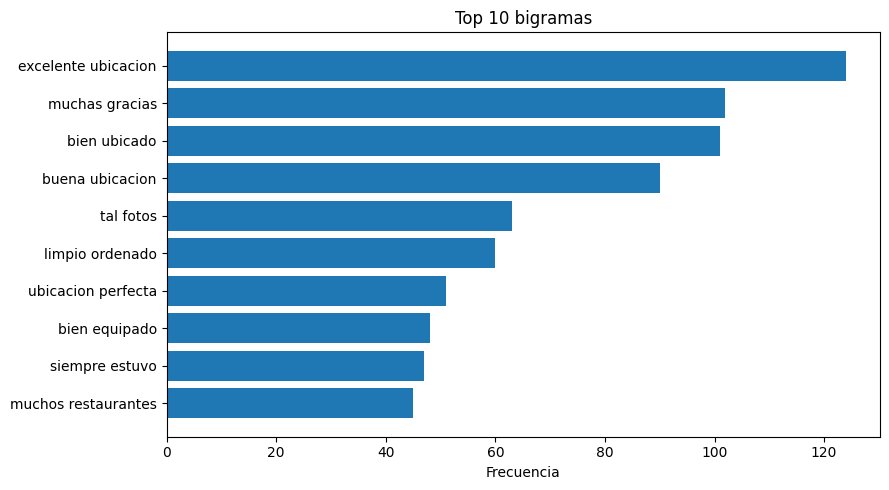

## Trigramas

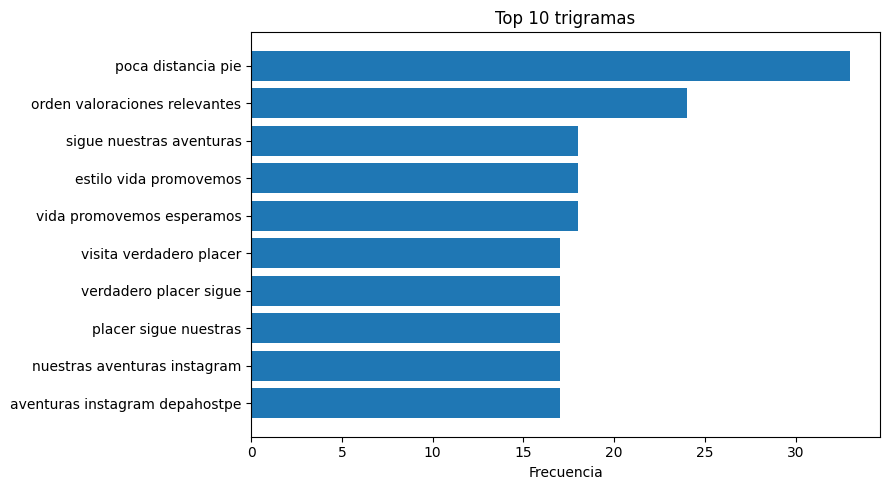

## Palabras frecuentes

,Palabra,Frecuencia
0,excelente,631
1,ubicacion,500
2,bien,477
3,limpio,434
4,buena,351
5,estadia,324
6,anfitrion,309
7,the,304
8,barranco,299
9,super,288


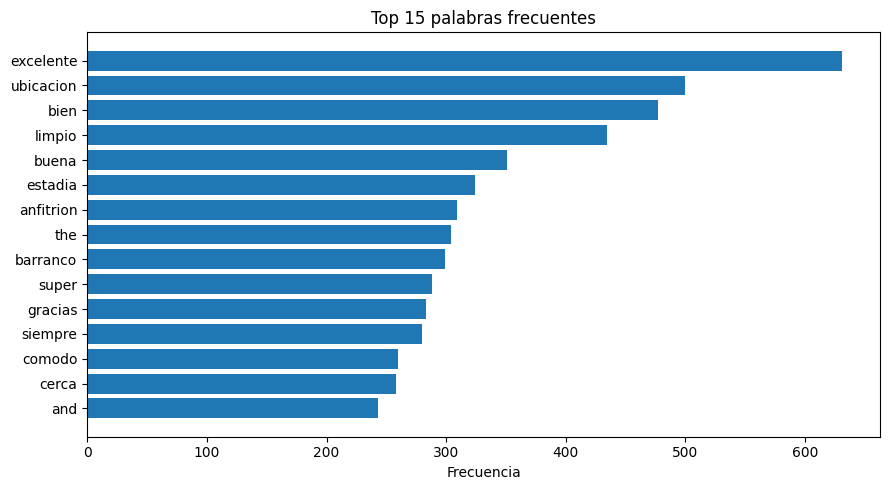

## Temas detectados

,Tema,Palabras clave,Cantidad estimada
0,Tema 1,"limpio, super, anfitrion, comodo, fotos, amabl...",1160
1,Tema 2,"excelente, ubicacion, servicio, anfitrion, imp...",357
2,Tema 3,"bien, ubicado, super, equipado, estuvo, recome...",292
3,Tema 4,"gracias, muchas, nuevamente, comentario, recib...",285
4,Tema 5,"the, and, was, apartment, great, for, very, pl...",89
5,Tema 6,"buena, ubicacion, comunicacion, experiencia, o...",229
6,Tema 7,"estadia, semana, alrededor, necesario, alegra,...",181
7,Tema 8,"bonito, limpio, ordenado, comodo, acogedor, bo...",204


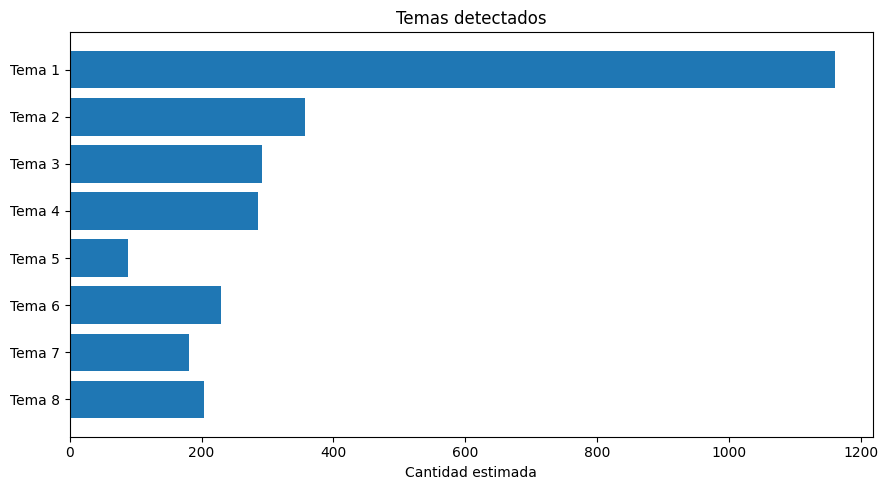

## Clusters

,cluster,comentarios,score_promedio
0,0,171,2.251462
1,1,268,1.018657
2,2,235,2.855319
3,3,2123,2.581253


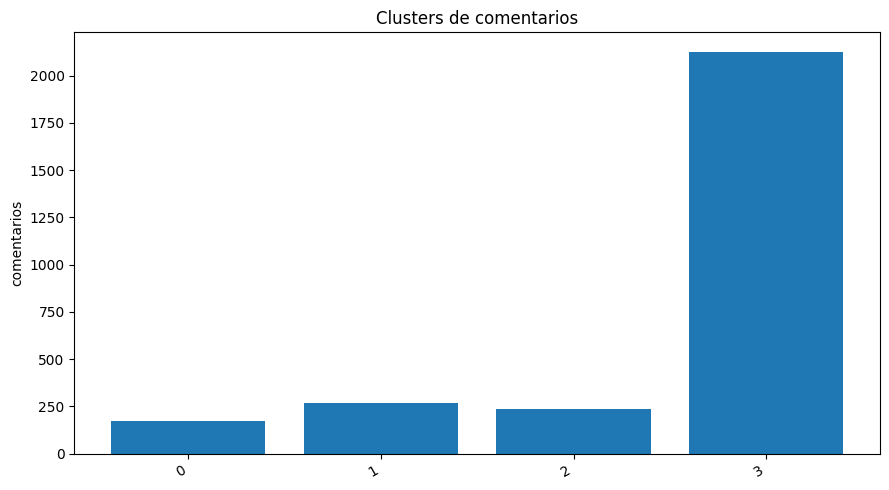

## Nube de palabras

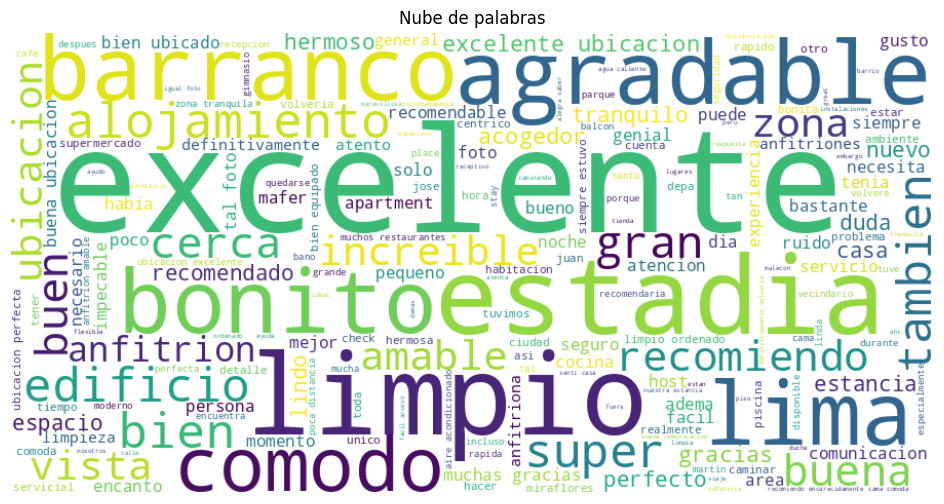

In [10]:
# ============================================================

output_dir = "salidas_analisis_sentimiento"
charts_dir = os.path.join(output_dir, "graficos")
os.makedirs(charts_dir, exist_ok=True)

sent3_df = df_valid["sentimiento_3"].value_counts().reset_index()
sent3_df.columns = ["Sentimiento", "Cantidad"]
sent3_df["Porcentaje"] = sent3_df["Cantidad"] / valid_comments

sent5_df = df_valid["sentimiento_5"].value_counts().reset_index()
sent5_df.columns = ["Sentimiento", "Cantidad"]
sent5_df["Porcentaje"] = sent5_df["Cantidad"] / valid_comments

emociones_df = df_valid["emocion"].value_counts().reset_index()
emociones_df.columns = ["Emoción", "Cantidad"]
emociones_df["Porcentaje"] = emociones_df["Cantidad"] / valid_comments

def save_show_pie(df_plot, label_col, value_col, title, filename):
    plt.figure(figsize=(7,5))
    plt.pie(df_plot[value_col], labels=df_plot[label_col], autopct="%1.1f%%", startangle=90)
    plt.title(title)
    path = os.path.join(charts_dir, filename)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path

def save_show_bar(df_plot, x_col, y_col, title, filename, horizontal=False):
    plt.figure(figsize=(9,5))
    if horizontal:
        plt.barh(df_plot[y_col], df_plot[x_col])
        plt.gca().invert_yaxis()
        plt.xlabel(x_col)
    else:
        plt.bar(df_plot[x_col].astype(str), df_plot[y_col])
        plt.xticks(rotation=30, ha="right")
        plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    path = os.path.join(charts_dir, filename)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path

display(Markdown("# 5. Gráficos principales"))

display(Markdown("## Distribución de sentimientos"))
display(format_percent_columns(sent3_df))
p_sent = save_show_pie(sent3_df, "Sentimiento", "Cantidad", "Distribución de sentimientos", "sentimientos.png")

display(Markdown("## Sentimiento en 5 clases"))
display(format_percent_columns(sent5_df))
p_sent5 = save_show_bar(sent5_df, "Sentimiento", "Cantidad", "Sentimiento en 5 clases", "sentimiento_5_clases.png")

display(Markdown("## Emociones"))
display(format_percent_columns(emociones_df))
p_emoc = save_show_bar(emociones_df, "Cantidad", "Emoción", "Distribución de emociones", "emociones.png", horizontal=True)

display(Markdown("## Aspectos ABSA"))
display(format_percent_columns(absa_summary))
p_absa = os.path.join(charts_dir, "aspectos_absa.png")
if len(absa_summary) > 0:
    plt.figure(figsize=(10,6))
    x = np.arange(len(absa_summary))
    plt.bar(x, absa_summary["Positivo"], label="Positivo")
    plt.bar(x, absa_summary["Neutral"], bottom=absa_summary["Positivo"], label="Neutral")
    plt.bar(x, absa_summary["Negativo"], bottom=absa_summary["Positivo"] + absa_summary["Neutral"], label="Negativo")
    plt.xticks(x, absa_summary["Aspecto"], rotation=35, ha="right")
    plt.ylabel("Cantidad")
    plt.title("Sentimiento por aspecto")
    plt.legend()
    plt.tight_layout()
    plt.savefig(p_absa, dpi=200, bbox_inches="tight")
    plt.show()

display(Markdown("## Bigramas"))
p_bi = save_show_bar(bigramas_df.head(10), "Frecuencia", "N-grama", "Top 10 bigramas", "bigramas.png", horizontal=True)

display(Markdown("## Trigramas"))
p_tri = save_show_bar(trigramas_df.head(10), "Frecuencia", "N-grama", "Top 10 trigramas", "trigramas.png", horizontal=True)

display(Markdown("## Palabras frecuentes"))
display(palabras_df.head(30))
p_pal = save_show_bar(palabras_df.head(15), "Frecuencia", "Palabra", "Top 15 palabras frecuentes", "palabras.png", horizontal=True)

display(Markdown("## Temas detectados"))
display(temas_df)
p_tem = save_show_bar(temas_df, "Cantidad estimada", "Tema", "Temas detectados", "temas.png", horizontal=True)

display(Markdown("## Clusters"))
display(clusters_df)
p_clu = save_show_bar(clusters_df, "cluster", "comentarios", "Clusters de comentarios", "clusters.png")

if WORDCLOUD_OK and len(tokens) > 0:
    display(Markdown("## Nube de palabras"))
    wc = WordCloud(width=900, height=450, background_color="white").generate(" ".join(tokens))
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nube de palabras")
    p_wc = os.path.join(charts_dir, "nube_palabras.png")
    plt.savefig(p_wc, dpi=200, bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# 10. Exportar Excel

In [11]:
# ============================================================

excel_file = os.path.join(output_dir, "Cuadro_Control_Analisis_Sentimiento_G4_FINAL.xlsx")

def id_airbnb_a_texto(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()

    # Si viene como 12345.0
    if re.fullmatch(r"\d+\.0", s):
        return s[:-2]

    # Si viene como notación científica: 1.135034995673292e+18
    if re.search(r"[eE]", s):
        return format(Decimal(s), "f").split(".")[0]

    return s

for temp_df in [df_valid, absa_df]:
    if "ID Airbnb" in temp_df.columns:
        temp_df["ID Airbnb"] = temp_df["ID Airbnb"].apply(id_airbnb_a_texto).astype("string")
    if "#Review" in temp_df.columns:
        temp_df["#Review"] = temp_df["#Review"].astype("string").str.replace(r"\.0$", "", regex=True)

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    kpis_df.to_excel(writer, sheet_name="KPIs", index=False)
    sent3_df.to_excel(writer, sheet_name="Sentimiento_3_clases", index=False)
    sent5_df.to_excel(writer, sheet_name="Sentimiento_5_clases", index=False)
    emociones_df.to_excel(writer, sheet_name="Emociones", index=False)
    absa_summary.to_excel(writer, sheet_name="Aspectos_ABSA", index=False)
    absa_df.to_excel(writer, sheet_name="Detalle_ABSA", index=False)
    temas_df.to_excel(writer, sheet_name="Temas_NMF", index=False)
    clusters_df.to_excel(writer, sheet_name="Clusters", index=False)
    bigramas_df.to_excel(writer, sheet_name="Bigramas", index=False)
    trigramas_df.to_excel(writer, sheet_name="Trigramas", index=False)
    palabras_df.to_excel(writer, sheet_name="Palabras_Frecuentes", index=False)
    df_valid.to_excel(writer, sheet_name="Comentarios_Analizados", index=False)

    contexto = pd.DataFrame({
        "Sección": [
            "Propósito de la aplicación",
            "Fuente de datos 1",
            "Fuente de datos 2",
            "Fuente de datos 3",
            "Variables textuales",
            "Variables numéricas",
            "Variables visuales"
        ],
        "Descripción": [
            "Monitorear automáticamente la percepción de huéspedes mediante IA y NLP.",
            "Comentarios de huéspedes procesados por el módulo LLM/NLP.",
            "Variables del alojamiento, como precio, rating, disponibilidad y número de reviews.",
            "Imágenes del alojamiento para análisis visual mediante CNN.",
            "Sentimiento, emoción, aspecto, tema, bigramas y trigramas.",
            "Precio, rating, número de reviews, disponibilidad y servicios.",
            "Limpieza visual, iluminación, estado de ambientes y calidad percibida."
        ]
    })
    contexto.to_excel(writer, sheet_name="Contexto_Industrial", index=False)

    restricciones = pd.DataFrame({
        "Restricción": ["Calidad de datos textuales", "Escalabilidad y recursos computacionales"],
        "Naturaleza": [
            "Comentarios con errores, textos cortos o lenguaje informal.",
            "Procesamiento de grandes volúmenes de texto e integración futura con imágenes."
        ],
        "Impacto": [
            "Puede afectar la precisión del análisis NLP.",
            "Puede requerir GPU, procesamiento por lotes y almacenamiento optimizado."
        ],
        "KPI asociado": [
            "Porcentaje de comentarios válidos y tasa de comentarios neutrales.",
            "Tiempo promedio de procesamiento y tasa de actualización del dashboard."
        ]
    })
    restricciones.to_excel(writer, sheet_name="Restricciones_KPIs", index=False)

    conclusiones = pd.DataFrame({
        "Tipo": [
            "Conclusión 1", "Conclusión 2", "Conclusión 3", "Conclusión 4",
            "Recomendación 1", "Recomendación 2", "Recomendación 3", "Recomendación 4"
        ],
        "Detalle": [
            f"Se analizaron {valid_comments:,} comentarios válidos de {total_rows:,} registros.",
            f"La percepción general es {pct_pos:.2%} positiva, {pct_neu:.2%} neutral y {pct_neg:.2%} negativa.",
            f"El aspecto mejor valorado fue {aspecto_mejor} y el aspecto crítico fue {aspecto_critico}.",
            f"La emoción predominante fue {emocion_predominante}.",
            "Mantener estándares de atención, limpieza y ubicación.",
            "Diseñar acciones de mejora sobre el aspecto crítico.",
            "Actualizar el dashboard periódicamente.",
            "Integrar el NLP con MLP y CNN en una arquitectura multimodal."
        ]
    })
    conclusiones.to_excel(writer, sheet_name="Conclusiones", index=False)

# Formato Excel e inserción de dashboard
wb = openpyxl.load_workbook(excel_file)

# Formato de porcentajes en hojas exportadas
percent_formats = {
    "KPIs": ["B5:B9"],
    "Sentimiento_3_clases": ["C2:C10"],
    "Sentimiento_5_clases": ["C2:C10"],
    "Emociones": ["C2:C20"],
    "Aspectos_ABSA": ["F2:G20"]
}
for sheet, ranges in percent_formats.items():
    if sheet in wb.sheetnames:
        ws_fmt = wb[sheet]
        for rg in ranges:
            for row in ws_fmt[rg]:
                for cell in row:
                    if isinstance(cell.value, (int, float)):
                        cell.number_format = "0.00%"

ws_dash = wb.create_sheet("Dashboard_Ejecutivo", 0)

title_fill = PatternFill("solid", fgColor="1F4E78")
header_fill = PatternFill("solid", fgColor="D9EAF7")
white_font = Font(color="FFFFFF", bold=True)
bold_font = Font(bold=True)
thin = Side(style="thin", color="BFBFBF")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

ws_dash["A1"] = "CUADRO DE CONTROL - ANÁLISIS DE SENTIMIENTO AIRBNB"
ws_dash["A1"].font = Font(bold=True, color="FFFFFF", size=14)
ws_dash["A1"].fill = title_fill
ws_dash.merge_cells("A1:H1")

dashboard_rows = [
    ["Indicador", "Valor"],
    ["Filas totales", total_rows],
    ["Comentarios válidos", valid_comments],
    ["Comentarios descartados", discarded_comments],
    ["% Positivos", pct_pos],
    ["% Neutrales", pct_neu],
    ["% Negativos", pct_neg],
    ["Índice general de satisfacción", pct_pos],
    ["Índice de sentimiento neto", sentimiento_neto],
    ["Aspecto mejor valorado", aspecto_mejor],
    ["Aspecto crítico", aspecto_critico],
    ["Emoción predominante", emocion_predominante],
]
for r_idx, row in enumerate(dashboard_rows, start=3):
    ws_dash.cell(r_idx, 1, row[0])
    ws_dash.cell(r_idx, 2, row[1])
    for c in range(1,3):
        ws_dash.cell(r_idx,c).border = border
        ws_dash.cell(r_idx,c).alignment = Alignment(vertical="center", wrap_text=True)
        if r_idx == 3:
            ws_dash.cell(r_idx,c).fill = title_fill
            ws_dash.cell(r_idx,c).font = white_font
for row in range(7, 12):
    ws_dash.cell(row,2).number_format = "0.00%"

img_positions = [
    (p_sent, "D3"), (p_emoc, "D20"), (p_absa, "D37"),
    (p_bi, "A20"), (p_tri, "A37"), (p_tem, "A54")
]
for img_path, pos in img_positions:
    if os.path.exists(img_path):
        img = XLImage(img_path)
        img.width = 420
        img.height = 260
        ws_dash.add_image(img, pos)


# Hoja1: tablas dinamicas/resumen por alojamiento para uso en fusion tardia
if "Hoja1" in wb.sheetnames:
    del wb["Hoja1"]
ws_pivot = wb.create_sheet("Hoja1")
ws_pivot["A1"] = "TABLAS DINAMICAS - SENTIMIENTO POR ALOJAMIENTO"
ws_pivot["A1"].font = Font(bold=True, size=14, color="FFFFFF")
ws_pivot["A1"].fill = title_fill
ws_pivot.merge_cells("A1:U1")

sent_pivot = pd.crosstab(
    df_valid["ID Airbnb"].astype("string"),
    df_valid["sentimiento_3"],
    normalize="index"
).reset_index()
sent_pivot.columns.name = None
for col in ["Negativo", "Neutral", "Positivo"]:
    if col not in sent_pivot.columns:
        sent_pivot[col] = 0.0
review_counts = df_valid.groupby(df_valid["ID Airbnb"].astype("string"))["#Review"].count().rename("Reviews")
sent_pivot = sent_pivot.merge(review_counts, left_on="ID Airbnb", right_index=True, how="left")
sent_pivot["Score rese?as fusion"] = (
    (sent_pivot["Positivo"] + 0.5 * sent_pivot["Neutral"]) * 100
).round(1)
sent_pivot["Confianza rese?as"] = (
    np.log10(sent_pivot["Reviews"] + 1) / np.log10(60) * 100
).clip(upper=100).round(1)
sent_pivot = sent_pivot[["ID Airbnb", "Negativo", "Neutral", "Positivo", "Reviews", "Score rese?as fusion", "Confianza rese?as"]]

ranking_pivot = sent_pivot.sort_values(
    ["Score rese?as fusion", "Reviews"], ascending=[False, False]
).reset_index(drop=True)

emotion_pivot = pd.crosstab(
    df_valid["ID Airbnb"].astype("string"),
    df_valid["emocion"],
    normalize="index"
).reset_index()
emotion_pivot.columns.name = None
preferred_emotions = ["Alegr?a", "Confianza", "Satisfacci?n", "Sorpresa", "Neutralidad", "Decepci?n", "Enojo", "Frustraci?n", "Tristeza"]
for col in preferred_emotions:
    if col not in emotion_pivot.columns:
        emotion_pivot[col] = 0.0
emotion_pivot = emotion_pivot[["ID Airbnb"] + preferred_emotions]

if len(absa_df) > 0:
    absa_pivot = pd.crosstab(
        [absa_df["ID Airbnb"].astype("string"), absa_df["Aspecto"]],
        absa_df["Sentimiento"],
        normalize="index"
    ).reset_index()
    absa_pivot.columns.name = None
    for col in ["Negativo", "Neutral", "Positivo"]:
        if col not in absa_pivot.columns:
            absa_pivot[col] = 0.0
    absa_counts = absa_df.groupby([absa_df["ID Airbnb"].astype("string"), "Aspecto"])["Comentario"].count().rename("Menciones")
    absa_pivot = absa_pivot.merge(absa_counts, left_on=["ID Airbnb", "Aspecto"], right_index=True, how="left")
    absa_pivot = absa_pivot[["ID Airbnb", "Aspecto", "Negativo", "Neutral", "Positivo", "Menciones"]]
else:
    absa_pivot = pd.DataFrame(columns=["ID Airbnb", "Aspecto", "Negativo", "Neutral", "Positivo", "Menciones"])

def write_df(ws, df, start_row, start_col, title):
    ws.cell(start_row, start_col, title)
    ws.cell(start_row, start_col).font = Font(bold=True, color="FFFFFF")
    ws.cell(start_row, start_col).fill = title_fill
    for c_idx, col_name in enumerate(df.columns, start=start_col):
        cell = ws.cell(start_row + 1, c_idx, col_name)
        cell.font = bold_font
        cell.fill = header_fill
        cell.border = border
    for r_idx, row in enumerate(df.itertuples(index=False), start=start_row + 2):
        for c_idx, value in enumerate(row, start=start_col):
            cell = ws.cell(r_idx, c_idx, value)
            cell.border = border
            if df.columns[c_idx - start_col] == "ID Airbnb":
                cell.number_format = "@"
                cell.value = str(value)
            elif isinstance(value, float):
                if 0 <= value <= 1:
                    cell.number_format = "0.00%"
                else:
                    cell.number_format = "0.0"

write_df(ws_pivot, sent_pivot, 3, 1, "Distribucion porcentual de sentimiento por alojamiento")
write_df(ws_pivot, ranking_pivot[["ID Airbnb", "Score rese?as fusion", "Confianza rese?as", "Reviews"]], 3, 9, "Ranking y score textual para fusion tardia")
write_df(ws_pivot, emotion_pivot, 3, 14, "Distribucion de emociones por alojamiento")
write_df(ws_pivot, absa_pivot, max(len(sent_pivot), len(emotion_pivot)) + 8, 1, "ABSA por alojamiento y aspecto")

for row in range(5, 5 + len(sent_pivot)):
    for col in [2, 3, 4]:
        ws_pivot.cell(row, col).number_format = "0.00%"
for row in range(5, 5 + len(emotion_pivot)):
    for col in range(15, 24):
        ws_pivot.cell(row, col).number_format = "0.00%"

for ws in wb.worksheets:
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            if cell.value is not None:
                max_len = max(max_len, len(str(cell.value)))
            if cell.row == 1:
                cell.font = bold_font
                cell.fill = header_fill
                cell.border = border
        ws.column_dimensions[col_letter].width = min(max_len + 2, 45)

wb.save(excel_file)


In [ ]:
# ============================================================
# 12. Descargar archivos

In [12]:
# ============================================================

zip_file = os.path.join(output_dir, "Graficos_Analisis_Sentimiento_G4_FINAL.zip")
with zipfile.ZipFile(zip_file, "w") as z:
    for root, dirs, file_names in os.walk(charts_dir):
        for f in file_names:
            full_path = os.path.join(root, f)
            z.write(full_path, arcname=f)

display(Markdown("# 6. Archivos generados"))
display(pd.DataFrame({
    "Archivo": ["Excel con dashboard", "ZIP de gráficos"],
    "Ruta": [excel_file, zip_file]
}))

files.download(excel_file)
files.download(zip_file)


# 6. Archivos generados

,Archivo,Ruta
0,Excel con dashboard,salidas_analisis_sentimiento/Cuadro_Control_An...
1,ZIP de gráficos,salidas_analisis_sentimiento/Graficos_Analisis...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>